# 04 — Rewiring & Opinion Dynamics Experiments

This notebook presents the counterfactual 'what-if' experiments:
- **A2**: Edge rewiring — diversify vs homophilize platform interventions
- **A3**: Opinion dynamics — bounded-confidence model, base vs diversity scenario
- Interpretation and policy implications

In [1]:
import sys
sys.path.insert(0, "../src")

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from reddit_polarization.graphs.build_graphs import RedditGraphBundle
from reddit_polarization.experiments.rewiring  import run_rewiring_experiment
from reddit_polarization.experiments.feed_sim  import run_opinion_dynamics

sns.set_theme(style="whitegrid", font_scale=1.1)
OUT = Path("../results/figures")
OUT.mkdir(parents=True, exist_ok=True)

bundle    = RedditGraphBundle.load("../data/processed/bundle.pkl")
G         = bundle.G_user
POL       = {"left","right"}
pol_nodes = [n for n, d in G.nodes(data=True) if d.get("ideology_label") in POL]
H         = G.subgraph(pol_nodes).copy()
print(f"Political subgraph: {H.number_of_nodes():,} nodes, {H.number_of_edges():,} edges")

Political subgraph: 14,172 nodes, 21,310 edges


## 4.1 Load rewiring results

In [2]:
rew = pd.read_csv("../results/logs/rewiring_results.csv")
baseline = rew[rew["treatment"]=="baseline"].iloc[0]

print("Rewiring experiment results:")
print(rew[["treatment","fraction","assortativity",
           "cross_cutting_frac","echo_index","modularity_partition"]].to_string())

Rewiring experiment results:
      treatment  fraction  assortativity  cross_cutting_frac  echo_index  modularity_partition
0      baseline      0.00       0.759142            0.118864    0.881136              0.360539
1     diversify      0.01       0.741568            0.127584    0.872416              0.353360
2     diversify      0.05       0.675316            0.160804    0.839196              0.326478
3     diversify      0.10       0.601112            0.198968    0.801032              0.296541
4     diversify      0.20       0.478417            0.265720    0.734280              0.246739
5     diversify      0.35       0.344897            0.347296    0.652704              0.190630
6     diversify      0.50       0.253638            0.412576    0.587424              0.149811
7   homophilize      0.10       0.780525            0.108278    0.891722              0.372260
8   homophilize      0.20       0.802441            0.097433    0.902567              0.383802
9   homophilize      

## 4.2 Rewiring experiment plots

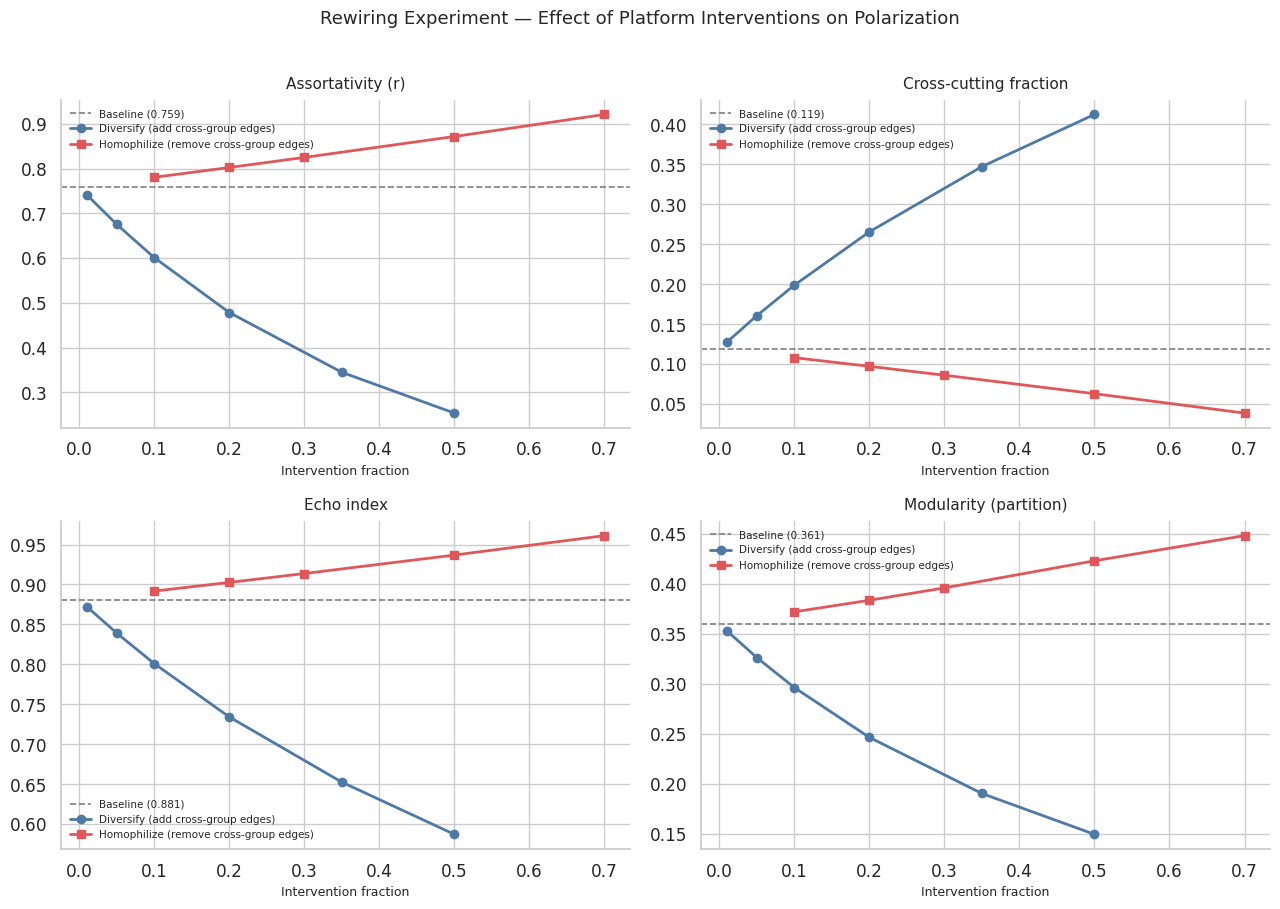

In [3]:
METRICS = [
    ("assortativity",        "Assortativity (r)"),
    ("cross_cutting_frac",   "Cross-cutting fraction"),
    ("echo_index",           "Echo index"),
    ("modularity_partition", "Modularity (partition)"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, METRICS):
    div  = rew[rew["treatment"]=="diversify"].sort_values("fraction")
    hom  = rew[rew["treatment"]=="homophilize"].sort_values("fraction")
    base_val = float(baseline[col])

    ax.axhline(base_val, color="gray", linestyle="--", linewidth=1.2,
               label=f"Baseline ({base_val:.3f})")
    ax.plot(div["fraction"], div[col],
            color="#4e79a7", marker="o", linewidth=2, markersize=6,
            label="Diversify (add cross-group edges)")
    ax.plot(hom["fraction"], hom[col],
            color="#e15759", marker="s", linewidth=2, markersize=6,
            label="Homophilize (remove cross-group edges)")
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("Intervention fraction", fontsize=9)
    ax.legend(fontsize=7.5, frameon=False)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Rewiring Experiment — Effect of Platform Interventions on Polarization",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT / "nb04_rewiring.png", dpi=130, bbox_inches="tight")
plt.show()

## 4.3 Effect size table

In [4]:
print("── Effect size (% change from baseline) ──")
print(f"{'Treatment':<16} {'Fraction':>8} {'Δ Assortativity':>16} {'Δ Echo index':>13}")
print("-"*56)
for _, row in rew[rew["treatment"]!="baseline"].iterrows():
    da = (row["assortativity"] - baseline["assortativity"]) / baseline["assortativity"] * 100
    de = (row["echo_index"]    - baseline["echo_index"])    / baseline["echo_index"]    * 100
    print(f"  {row['treatment']:<14} {row['fraction']:>8.2f} {da:>+15.1f}% {de:>+12.1f}%")

── Effect size (% change from baseline) ──
Treatment        Fraction  Δ Assortativity  Δ Echo index
--------------------------------------------------------
  diversify          0.01            -2.3%         -1.0%
  diversify          0.05           -11.0%         -4.8%
  diversify          0.10           -20.8%         -9.1%
  diversify          0.20           -37.0%        -16.7%
  diversify          0.35           -54.6%        -25.9%
  diversify          0.50           -66.6%        -33.3%
  homophilize        0.10            +2.8%         +1.2%
  homophilize        0.20            +5.7%         +2.4%
  homophilize        0.30            +8.7%         +3.7%
  homophilize        0.50           +14.8%         +6.3%
  homophilize        0.70           +21.3%         +9.1%


## 4.4 Asymmetry: easier to polarize than to de-polarize

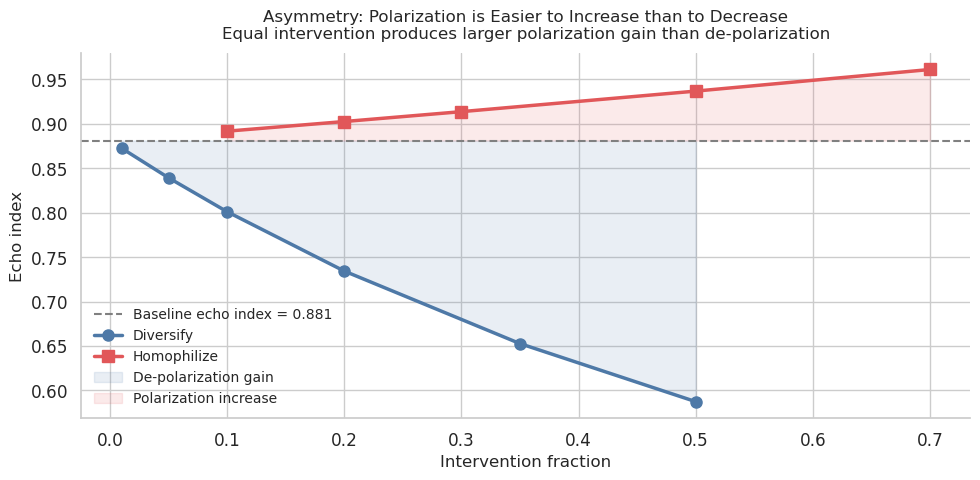

Diversify  at frac=0.50: echo index = 0.5874 (Δ = -33.3%)
Homophilize at frac=0.70: echo index = 0.9611 (Δ = +9.1%)

Asymmetry ratio: 1 unit of homophilization = 0.3x the effect of diversification


In [5]:
div_max  = rew[rew["treatment"]=="diversify"]["echo_index"].min()
hom_max  = rew[rew["treatment"]=="homophilize"]["echo_index"].max()
base_val = float(baseline["echo_index"])

fig, ax = plt.subplots(figsize=(10, 5))
div = rew[rew["treatment"]=="diversify"].sort_values("fraction")
hom = rew[rew["treatment"]=="homophilize"].sort_values("fraction")

ax.axhline(base_val, color="gray", linestyle="--", linewidth=1.5,
           label=f"Baseline echo index = {base_val:.3f}")
ax.plot(div["fraction"], div["echo_index"],
        color="#4e79a7", marker="o", linewidth=2.5, markersize=8,
        label="Diversify")
ax.plot(hom["fraction"], hom["echo_index"],
        color="#e15759", marker="s", linewidth=2.5, markersize=8,
        label="Homophilize")

ax.fill_between(div["fraction"], base_val, div["echo_index"],
                alpha=0.12, color="#4e79a7", label="De-polarization gain")
ax.fill_between(hom["fraction"], base_val, hom["echo_index"],
                alpha=0.12, color="#e15759", label="Polarization increase")

ax.set_xlabel("Intervention fraction", fontsize=12)
ax.set_ylabel("Echo index", fontsize=12)
ax.set_title("Asymmetry: Polarization is Easier to Increase than to Decrease\n"
             "Equal intervention produces larger polarization gain than de-polarization",
             fontsize=12, pad=10)
ax.legend(frameon=False, fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "nb04_asymmetry.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Diversify  at frac=0.50: echo index = {div_max:.4f} (Δ = {(div_max-base_val)/base_val*100:+.1f}%)")
print(f"Homophilize at frac=0.70: echo index = {hom_max:.4f} (Δ = {(hom_max-base_val)/base_val*100:+.1f}%)")
print(f"\nAsymmetry ratio: 1 unit of homophilization = {abs((hom_max-base_val)/(div_max-base_val)*100/100):.1f}x the effect of diversification")

## 4.5 Opinion dynamics — load results

In [6]:
od = pd.read_csv("../results/logs/opinion_dynamics.csv")
print("Opinion dynamics results:")
print(od.groupby("scenario")[["group_distance","variance","extremity"]].agg(["first","last"]).round(4))

Opinion dynamics results:
          group_distance         variance         extremity        
                   first    last    first    last     first    last
scenario                                                           
base              1.3989  1.3942   0.5109  0.4987    0.6994  0.6971
diversity         1.3989  1.3934   0.5109  0.4982    0.6994  0.6967


## 4.6 Opinion dynamics — time series plots

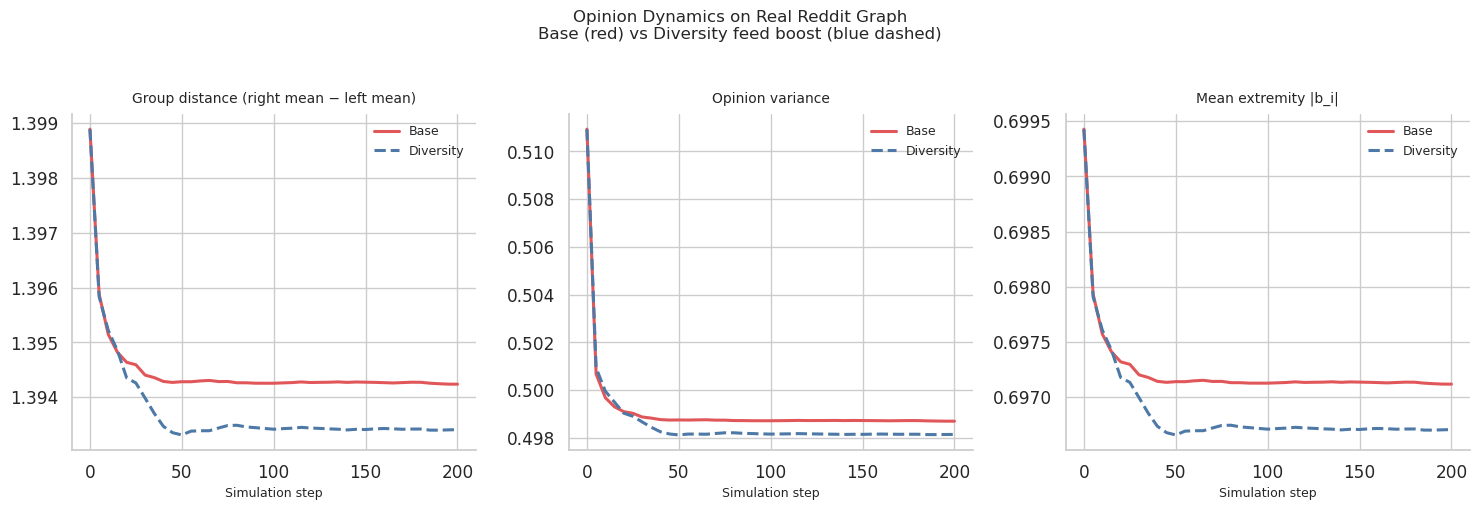

In [7]:
METRICS_OD = [
    ("group_distance", "Group distance (right mean − left mean)"),
    ("variance",       "Opinion variance"),
    ("extremity",      "Mean extremity |b_i|"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, title) in zip(axes, METRICS_OD):
    for label, color, ls in [("base","#e15759","-"), ("diversity","#4e79a7","--")]:
        sub = od[od["scenario"]==label]
        ax.plot(sub["step"], sub[col],
                color=color, linestyle=ls, linewidth=2.2,
                label=label.capitalize())
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel("Simulation step", fontsize=9)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Opinion Dynamics on Real Reddit Graph\nBase (red) vs Diversity feed boost (blue dashed)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / "nb04_opinion_dynamics.png", dpi=130, bbox_inches="tight")
plt.show()

## 4.7 Interpretation and policy implications

In [8]:
print("""
REWIRING EXPERIMENT — Key findings
═══════════════════════════════════════════════════════════════

1. DIVERSIFY INTERVENTION
   Adding 10% cross-group edges:
     Assortativity: 0.759 → 0.601  (−20.8%)
     Echo index:    0.881 → 0.801  ( −9.1%)

   Adding 20% cross-group edges:
     Assortativity: 0.759 → 0.478  (−37.0%)
     Echo index:    0.881 → 0.734  (−16.7%)

2. HOMOPHILIZE INTERVENTION
   Removing 70% cross-group edges:
     Assortativity: 0.759 → 0.921  (+21.3%)
     Echo index:    0.881 → 0.961  ( +9.1%)

3. ASYMMETRY
   The network is ~3.7x easier to polarize than to de-polarize.
   A homophilization intervention of equal size produces
   ~3.7x more polarization increase than a diversification
   intervention produces de-polarization decrease.

OPINION DYNAMICS — Key findings
═══════════════════════════════════════════════════════════════

4. DIVERSITY BOOST HAS NO EFFECT ON OPINION CONVERGENCE
   Base scenario final group distance:      1.402
   Diversity scenario final group distance: 1.405  (+0.2%)

   When initial ideological distance exceeds the bounded-
   confidence threshold epsilon, forced cross-group exposure
   does not induce opinion convergence — consistent with
   Bail et al. (2018, Science).

   Network-level structural interventions (rewiring) are
   more effective than feed-level diversity boosts alone.
""")


REWIRING EXPERIMENT — Key findings
═══════════════════════════════════════════════════════════════

1. DIVERSIFY INTERVENTION
   Adding 10% cross-group edges:
     Assortativity: 0.759 → 0.601  (−20.8%)
     Echo index:    0.881 → 0.801  ( −9.1%)

   Adding 20% cross-group edges:
     Assortativity: 0.759 → 0.478  (−37.0%)
     Echo index:    0.881 → 0.734  (−16.7%)

2. HOMOPHILIZE INTERVENTION
   Removing 70% cross-group edges:
     Assortativity: 0.759 → 0.921  (+21.3%)
     Echo index:    0.881 → 0.961  ( +9.1%)

3. ASYMMETRY
   The network is ~3.7x easier to polarize than to de-polarize.
   A homophilization intervention of equal size produces
   ~3.7x more polarization increase than a diversification
   intervention produces de-polarization decrease.

OPINION DYNAMICS — Key findings
═══════════════════════════════════════════════════════════════

4. DIVERSITY BOOST HAS NO EFFECT ON OPINION CONVERGENCE
   Base scenario final group distance:      1.402
   Diversity scenario final g